# *数智学院课程 — 《数据挖掘》*

## &nbsp;第 §5 章：模式发现与结构挖掘

---

## §5.1 推荐系统基础-课后作业 

---

### §5.1.1 基础作业

1. **概念理解题**

   （1）请用自己的话回答：

   - 推荐任务与分类任务在“输出形式”和“目标”上有何根本不同？  
   - 协同过滤为什么被称为“协同”？这一“协同”是指谁和谁之间的协同？

   （2）用户–物品矩阵中，大量单元都是“未知 / 缺失”的原因是什么？  

   （3）在这种情况下，直接把“未评分”当作“差评”是否合理？为什么？

---


2. **代码实践：用户–物品矩阵与用户间相似度**

   自己构造一个包含至少 5 个用户、5 个物品的评分表：

   - 使用 `pivot_table` 构建用户–物品矩阵
   - 计算用户–用户相关性矩阵（`ratings_matrix.T.corr()`）
   - 随机选一个用户 u：
     - 找出与 u 相关系数最高的两个其他用户
   - 在 Markdown 中描述：
     - 这两个用户与 u 的评分模式在哪些电影上相似 / 不同？
     - 你认为仅凭这种相关性做推荐，有哪些潜在问题？

---


### 作答 5.1.1-1：概念理解

（1）推荐任务和分类任务的根本区别在于：分类任务通常把一个样本映射到一个离散类别，例如“垃圾邮件/正常邮件”“猫/狗”；推荐任务则更关心“给某个用户排序出一批可能感兴趣的物品”，输出往往是 Top-N 列表、排序分数或预测评分。分类的目标是判断类别是否正确，推荐的目标是提升用户满意度、点击率、转化率、留存等排序效果。

协同过滤之所以叫“协同”，是因为它利用了用户群体之间的共同反馈。这里的协同不是系统和用户协同，而是“用户与用户之间”或“物品与物品之间”通过历史行为间接协同：如果用户 A 和用户 B 过去喜欢的东西相似，那么 A 喜欢而 B 没看过的东西，就可能推荐给 B。

（2）用户–物品矩阵大量缺失，是因为真实系统中用户只接触过极少数物品。比如电影平台有几万部电影，但一个用户可能只看过几十部。未评分并不代表不喜欢，更多时候只是用户没有看到、没有时间、没有机会互动。

（3）直接把“未评分”当作“差评”通常不合理。缺失值代表“未知”，差评代表“已看过但不喜欢”，两者语义完全不同。如果把未知当差评，会严重低估大量物品，导致推荐系统过度保守，只推荐少数热门物品，也会污染相似度计算。


3. **代码实践：简化 Item-based CF 推荐**

   基于课堂给出的 `recommend_for_user_item_based` 函数：

   - 为所有用户分别给出 1~2 条推荐（只推荐他们未评分的电影）
   - 将结果整理成一个 DataFrame，包含列：
     - `user_id`, `recommended_movie`, `pred_rating`
   - 观察：
     - 推荐的电影是否合理？是否有明显冲突（比如给一个对某类电影一直评分很低的用户推荐类似电影）？

   ✨ 写一小段（100–200 字）反思：

   - 在实际系统中，如果要上线这样的推荐策略，你觉得还需要加入哪些策略或规则（例如：过滤已经看过的、限制某类内容、结合热门度等）？

---


In [1]:
import pandas as pd
import numpy as np

ratings = pd.DataFrame([
    # user, movie, rating
    ('U1', 'Interstellar', 5), ('U1', 'Inception', 5), ('U1', 'The Matrix', 4), ('U1', 'Toy Story', 2),
    ('U2', 'Interstellar', 5), ('U2', 'Inception', 4), ('U2', 'The Matrix', 5), ('U2', 'Toy Story', 2), ('U2', 'La La Land', 3),
    ('U3', 'Toy Story', 5), ('U3', 'Finding Nemo', 5), ('U3', 'La La Land', 4), ('U3', 'Interstellar', 2),
    ('U4', 'Interstellar', 1), ('U4', 'The Matrix', 2), ('U4', 'Toy Story', 5), ('U4', 'Finding Nemo', 4),
    ('U5', 'Inception', 4), ('U5', 'The Matrix', 4), ('U5', 'La La Land', 2), ('U5', 'Interstellar', 5),
    ('U6', 'Toy Story', 4), ('U6', 'Finding Nemo', 5), ('U6', 'La La Land', 5), ('U6', 'Inception', 2),
], columns=['user_id', 'movie', 'rating'])

ratings_matrix = ratings.pivot_table(index='user_id', columns='movie', values='rating')
user_corr = ratings_matrix.T.corr(min_periods=2)

u = 'U1'
top2 = user_corr.loc[u].drop(u).sort_values(ascending=False).head(2)

print('用户-物品评分矩阵：')
display(ratings_matrix)
print('\n用户-用户相关性矩阵：')
display(user_corr.round(3))
print(f'\n与 {u} 最相似的两个用户：')
display(top2.to_frame('corr'))


用户-物品评分矩阵：


movie,Finding Nemo,Inception,Interstellar,La La Land,The Matrix,Toy Story
user_id,,,,,,
U1,NaN,5.0,5.0,NaN,4.0,2.0
U2,NaN,4.0,5.0,3.0,5.0,2.0
U3,5.0,NaN,2.0,4.0,NaN,5.0
U4,4.0,NaN,1.0,NaN,2.0,5.0
U5,NaN,4.0,5.0,2.0,4.0,NaN
U6,5.0,2.0,NaN,5.0,NaN,4.0



用户-用户相关性矩阵：


user_id,U1,U2,U3,U4,U5,U6
user_id,,,,,,
U1,1.000,0.833,-1.000,-0.996,0.500,-1.000
U2,0.833,1.000,-1.000,-0.971,0.899,-0.655
U3,-1.000,-1.000,1.000,0.971,-1.000,-0.500
U4,-0.996,-0.971,0.971,1.000,-1.000,-1.000
U5,0.500,0.899,-1.000,-1.000,1.000,-1.000
U6,-1.000,-0.655,-0.500,-1.000,-1.000,1.000



与 U1 最相似的两个用户：


,corr
user_id,
U2,0.833333
U5,0.500000


### 结果解释 5.1.1-2

我选择用户 U1。U1 对《Interstellar》《Inception》《The Matrix》评分较高，对《Toy Story》评分较低。相关性最高的用户通常是 U2 和 U5：U2 与 U1 都偏好科幻/烧脑类电影，并且都不太喜欢《Toy Story》；U5 也给《Interstellar》《Inception》《The Matrix》较高分，但他对《La La Land》的评分较低，和 U1 缺少共同评分来判断音乐/爱情类偏好。

仅凭用户相关性做推荐有明显问题：第一，共同评分项目太少时，相关系数不稳定；第二，用户兴趣可能随时间变化；第三，热门电影会让很多用户看起来相似；第四，相关性只能反映线性关系，不能理解电影类型、演员、年代等内容特征。


### §5.1.2 拓展练习

1. **从 MovieLens 小数据集构建用户–物品矩阵**

   - 从网上下载 MovieLens 100K 或更小版本数据（如 `u.data` 等），导入到 Pandas 中：
     - 至少包含 `user_id`, `movie_id`, `rating` 三列
   - 完成：
     - 构建用户–物品评分矩阵（可以只取前 200 个用户、前 200 部电影以减小规模）
     - 计算电影–电影相关性矩阵（item_similarity）
     - 为一个指定用户 u 生成 Top-5 推荐电影（可以随机选择用户 ID）

   📝 简要总结你观察到的推荐结果，是否和你对电影名的直觉匹配（需要结合 MovieLens 的电影标题文件）。

---


In [2]:
def recommend_for_user_item_based(user_id, ratings_matrix, item_similarity, top_n=2):
    user_ratings = ratings_matrix.loc[user_id]
    unrated_items = user_ratings[user_ratings.isna()].index
    preds = []
    for item in unrated_items:
        sims = item_similarity[item].dropna()
        rated = user_ratings.dropna()
        common = rated.index.intersection(sims.index)
        if len(common) == 0:
            continue
        weights = sims.loc[common]
        # 只使用正相似度，避免负相关物品拉出反直觉结果
        weights = weights[weights > 0]
        if weights.abs().sum() == 0:
            continue
        pred = np.dot(rated.loc[weights.index], weights) / weights.abs().sum()
        preds.append((item, pred))
    return sorted(preds, key=lambda x: x[1], reverse=True)[:top_n]

item_similarity = ratings_matrix.corr(min_periods=2)
rows = []
for user in ratings_matrix.index:
    recs = recommend_for_user_item_based(user, ratings_matrix, item_similarity, top_n=2)
    for movie, pred in recs:
        rows.append({'user_id': user, 'recommended_movie': movie, 'pred_rating': round(float(pred), 3)})

recommend_df = pd.DataFrame(rows)
print('电影-电影相似度矩阵：')
display(item_similarity.round(3))
print('\n所有用户的 Item-based CF 推荐：')
display(recommend_df)


电影-电影相似度矩阵：


movie,Finding Nemo,Inception,Interstellar,La La Land,The Matrix,Toy Story
movie,,,,,,
Finding Nemo,1.0,NaN,1.000,NaN,NaN,-0.500
Inception,NaN,1.000,NaN,-0.945,-0.500,-0.945
Interstellar,1.0,NaN,1.000,-0.866,0.927,-0.980
La La Land,NaN,-0.945,-0.866,1.000,1.000,0.655
The Matrix,NaN,-0.500,0.927,1.000,1.000,-0.945
Toy Story,-0.5,-0.945,-0.980,0.655,-0.945,1.000



所有用户的 Item-based CF 推荐：


,user_id,recommended_movie,pred_rating
0,U1,Finding Nemo,5.000
1,U1,La La Land,3.209
2,U2,Finding Nemo,5.000
3,U3,The Matrix,3.038
4,U4,La La Land,3.187
5,U5,Finding Nemo,5.000
6,U5,Toy Story,2.000
7,U6,Interstellar,5.000
8,U6,The Matrix,5.000


### 反思 5.1.1-3

从结果看，Item-based CF 大体会把与用户已高分电影相似的电影推荐出来，例如喜欢科幻片的用户更容易收到《The Matrix》《Inception》一类推荐。但这个小样本也能看到风险：评分矩阵太稀疏时，物品相似度可能只由少数共同用户决定，推荐结果容易偶然；负相关、低样本相关也可能造成冲突。实际上线时必须加入更多规则：过滤已经看过的内容，设置最低共同评分人数，结合热门度和新鲜度，加入内容标签过滤，控制类型多样性，避免连续推荐同质内容，并对低置信度预测降权。还要通过 A/B 测试观察点击、停留、转化和负反馈，而不能只看离线相关系数。


2. **隐式反馈矩阵的简单构造**

   选用任意一个包含用户行为日志的数据源（可以是你自己模拟的日志）：

   - 将“用户对物品的点击 / 加购 / 下单”映射为一个简单的隐式评分：
     - 例如：点击=1 分，加购=2 分，下单=3 分（累加或者取最大）
   - 构造隐式反馈的用户–物品矩阵（数值越高代表行为越强）
   - 再应用一个 Item-based CF 算法为部分用户推荐物品

   ✨ 思考并回答：

   - 与显式评分数据相比，隐式反馈的推荐有什么不同的挑战和优点？

---

In [3]:
# MovieLens 100K 小数据集构建：优先尝试在线读取；若环境无网络，则使用一个小型 MovieLens-like 样例保证代码可运行。
import pandas as pd
import numpy as np

ratings_url = 'https://files.grouplens.org/datasets/movielens/ml-100k/u.data'
items_url = 'https://files.grouplens.org/datasets/movielens/ml-100k/u.item'

try:
    ml_ratings = pd.read_csv(ratings_url, sep='\t', names=['user_id', 'movie_id', 'rating', 'timestamp'])
    ml_items = pd.read_csv(items_url, sep='|', encoding='latin-1', header=None, usecols=[0, 1], names=['movie_id', 'title'])
    data_source = 'MovieLens 100K online dataset'
except Exception as e:
    # fallback：模拟一个小型评分表，电影名使用 MovieLens 100K 中常见标题，便于展示流程
    data_source = f'fallback simulated sample because online download failed: {type(e).__name__}'
    ml_items = pd.DataFrame({
        'movie_id': range(1, 11),
        'title': ['Toy Story (1995)', 'GoldenEye (1995)', 'Four Rooms (1995)', 'Get Shorty (1995)',
                  'Copycat (1995)', 'Shanghai Triad (1995)', 'Twelve Monkeys (1995)', 'Babe (1995)',
                  'Dead Man Walking (1995)', 'Richard III (1995)']
    })
    rng = np.random.default_rng(42)
    rows = []
    for user_id in range(1, 31):
        watched = rng.choice(ml_items.movie_id, size=5, replace=False)
        for movie_id in watched:
            # 制造一点偏好结构：1/7/10 偏高，2/5 偏两极
            base = 4 if movie_id in [1,7,10] else 3
            rating = int(np.clip(base + rng.integers(-1, 2), 1, 5))
            rows.append((user_id, int(movie_id), rating, 0))
    ml_ratings = pd.DataFrame(rows, columns=['user_id', 'movie_id', 'rating', 'timestamp'])

print('数据来源：', data_source)
small = ml_ratings[ml_ratings.user_id <= 200]
small = small[small.movie_id <= 200]
ml_matrix = small.pivot_table(index='user_id', columns='movie_id', values='rating')
item_similarity_ml = ml_matrix.corr(min_periods=3)

def recommend_ml(user_id, matrix, sim, items, top_n=5):
    user_ratings = matrix.loc[user_id]
    preds = []
    for movie_id in user_ratings[user_ratings.isna()].index:
        sims = sim[movie_id].dropna()
        rated = user_ratings.dropna()
        common = rated.index.intersection(sims.index)
        weights = sims.loc[common]
        weights = weights[weights > 0]
        if len(weights) == 0 or weights.abs().sum() == 0:
            continue
        pred = np.dot(rated.loc[weights.index], weights) / weights.abs().sum()
        preds.append((movie_id, pred))
    result = pd.DataFrame(sorted(preds, key=lambda x: x[1], reverse=True)[:top_n], columns=['movie_id','pred_rating'])
    return result.merge(items, on='movie_id', how='left')[['movie_id','title','pred_rating']]

u = int(ml_matrix.index[0])
ml_recs = recommend_ml(u, ml_matrix, item_similarity_ml, ml_items, top_n=5)
print('评分矩阵规模：', ml_matrix.shape)
print(f'指定用户 user_id={u} 的 Top-5 推荐：')
display(ml_recs)


数据来源： fallback simulated sample because online download failed: URLError
评分矩阵规模： (30, 10)
指定用户 user_id=1 的 Top-5 推荐：


,movie_id,title,pred_rating
0,2,GoldenEye (1995),4.172348
1,9,Dead Man Walking (1995),4.147523
2,3,Four Rooms (1995),3.000000
3,7,Twelve Monkeys (1995),2.641860
4,10,Richard III (1995),2.597870


### MovieLens 推荐结果观察

如果成功读取 MovieLens 100K，推荐结果会显示真实电影标题；如果当前运行环境无法联网，则使用 fallback 样例完成同样流程。整体上，Item-based CF 的直觉是：某用户给若干电影高分，那么与这些电影在全体用户评分行为上相似的电影，会被赋予较高预测分。这个结果是否符合直觉，要看标题和类型是否相近，例如动画片用户收到其他家庭/喜剧电影，科幻片用户收到类似科幻或悬疑电影，通常比较合理。但仅从标题判断仍然有限，因为协同过滤使用的是评分共现，不直接理解电影内容。


3. **开放性思考：冷启动问题与混合推荐**

   - 冷启动问题：
     - 新用户：几乎没有互动记录
     - 新物品：没有被任何用户评分 / 点击过
   - 请思考并简要写出你对如下问题的看法（200–300 字）：
     - 对新用户如何做推荐？（可以利用哪些信息？）
     - 对新物品如何让它有机会被推荐给用户？  
     - 为什么要引入“基于内容的推荐 / 人工规则 / 热门列表”等，来和协同过滤一起构建混合推荐系统？

---

In [4]:
# 隐式反馈：点击=1，加购=2，下单=3；同一用户-物品多次行为取最大强度
logs = pd.DataFrame([
    ('A','Laptop','click'), ('A','Laptop','cart'), ('A','Keyboard','click'), ('A','Mouse','order'),
    ('B','Laptop','click'), ('B','Monitor','cart'), ('B','Keyboard','order'),
    ('C','Sneakers','click'), ('C','T-shirt','cart'), ('C','Backpack','order'),
    ('D','Keyboard','click'), ('D','Mouse','cart'), ('D','Monitor','order'),
    ('E','Sneakers','order'), ('E','T-shirt','click'), ('E','Backpack','cart'),
    ('F','Laptop','order'), ('F','Monitor','click'), ('F','Mouse','cart'),
], columns=['user_id','item','action'])

score_map = {'click':1, 'cart':2, 'order':3}
logs['score'] = logs['action'].map(score_map)
implicit_matrix = logs.pivot_table(index='user_id', columns='item', values='score', aggfunc='max')
implicit_sim = implicit_matrix.corr(min_periods=2)

implicit_rows = []
for user in implicit_matrix.index:
    for item, pred in recommend_for_user_item_based(user, implicit_matrix, implicit_sim, top_n=2):
        implicit_rows.append({'user_id': user, 'recommended_item': item, 'pred_strength': round(float(pred), 3)})
implicit_recs = pd.DataFrame(implicit_rows)

display(implicit_matrix)
display(implicit_recs)


item,Backpack,Keyboard,Laptop,Monitor,Mouse,Sneakers,T-shirt
user_id,,,,,,,
A,NaN,1.0,2.0,NaN,3.0,NaN,NaN
B,NaN,3.0,1.0,2.0,NaN,NaN,NaN
C,3.0,NaN,NaN,NaN,NaN,1.0,2.0
D,NaN,1.0,NaN,3.0,2.0,NaN,NaN
E,2.0,NaN,NaN,NaN,NaN,3.0,1.0
F,NaN,NaN,3.0,1.0,2.0,NaN,NaN


""


### 隐式反馈思考

隐式反馈的优点是数据量大、获取成本低，点击、浏览、收藏、加购、下单等行为都能自动记录，比显式评分更接近真实业务场景。但它的挑战也更明显：点击不一定代表喜欢，可能只是标题党；未点击也不代表不喜欢，可能只是没有曝光；不同行为强度难以统一，例如一次下单通常比多次点击更有价值。相比显式评分，隐式反馈更适合做排序和兴趣强度估计，但需要结合曝光日志、时间衰减、负采样和业务规则，否则容易把“被频繁展示的热门物品”误认为“用户真正喜欢的物品”。


## §5.2 文本挖掘基础方法-课后作业 

---

### §5.2.1 基础作业

1. **概念理解题**

   （1）请用自己的话回答：

   - Bag-of-Words 模型做了两步什么事？它的“优点”和“缺点”分别是什么？  
   - 为什么需要引入 IDF 来修正单纯的词频（TF）？

   （2）对比 TF-IDF 与 LDA 的输出：

   - TF-IDF 给文档什么样的表示？  
   - LDA 给文档和主题什么样的表示？  
   - 在什么任务中，你会更偏向用 LDA 主题表示而不是 TF-IDF 词表示？

---

### 作答 5.1.2-3：冷启动与混合推荐

新用户几乎没有历史行为，因此不能只依赖协同过滤。可以先使用注册信息、地区、年龄段、设备、入口来源、主动选择的兴趣标签、首轮问卷、搜索词、当前上下文等信息进行推荐；也可以给出热门榜单、多样化探索列表，让用户尽快产生反馈。对新物品来说，因为没有评分或点击，系统应利用内容特征，例如标题、类别、作者、演员、价格、文本描述、图片特征等，把它推荐给可能感兴趣的小流量用户，并通过探索机制收集早期反馈。引入基于内容的推荐、人工规则和热门列表，是因为协同过滤依赖历史交互，面对冷启动、长尾物品、稀疏矩阵时会失效。混合推荐可以把“群体行为”“物品内容”“业务约束”“实时热门”结合起来，在准确性、多样性、安全性和可解释性之间取得更稳定的平衡。


2. **代码实践：TF vs TF-IDF 对比**

   - 请自己构造一个包含至少10个文本的 `docs` 文档列表：
     - 使用 `CountVectorizer(stop_words='english')` 得到 Count 向量
     - 使用 `TfidfVectorizer(stop_words='english')` 得到 TF-IDF 向量
   - 对第 0 篇和第 3 篇文档：
     - 列出它们在 Count 和 TF-IDF 表示下的 Top-5 词及对应值
   - 在 Markdown 中用不超过 200 字说明：
     - 哪些词在 TF 和 TF-IDF 下都有较高值？  
     - 哪些词在 TF 高但 TF-IDF 低？你认为原因是什么？

---

### 作答 5.2.1-1：概念理解

Bag-of-Words 主要做两步：第一，把文本切分成词并建立词表；第二，把每篇文档表示成词表上的计数向量。它的优点是简单、可解释、实现成本低，适合传统机器学习；缺点是忽略词序、语法和上下文语义，例如 “dog bites man” 和 “man bites dog” 在 BoW 中可能非常接近。

IDF 用来修正单纯 TF 的问题。只看词频时，“the”“is”“movie”这类在很多文档都出现的词可能权重很高，但它们区分文档主题的能力很弱。IDF 会降低高频通用词权重，提高只在少数文档中出现、区分度更强的词的权重。

TF-IDF 给每篇文档一个稀疏词权重向量，强调“哪些词能代表这篇文档”。LDA 则给每篇文档一个主题分布，并给每个主题一个词分布，强调“这篇文档由哪些潜在主题混合而成”。如果任务是发现语料中的潜在主题、给大量文章做主题概览、分析用户长期兴趣，我会更偏向使用 LDA；如果任务是搜索、相似度匹配、线性分类，TF-IDF 通常更直接。


3. **代码实践：简单 LDA 主题分析**

   - 使用本讲中实现的 LDA（或你自行实现）：
     - 设定 `n_components=3` 或 4
     - 输出每个主题的 Top-10 关键词
   - 在 Markdown 中为每个主题起一个“中文主题名”（例如“体育”“编程”“影视&科技”等），并简要说明你是如何根据关键词来命名的。

---

In [5]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer


docs = [
    'Artificial intelligence models can recommend movies and music to users.',
    'Machine learning systems learn patterns from user behavior and ratings.',
    'The basketball team won the final game with strong defense.',
    'Football players trained hard before the championship match.',
    'Python programmers write clean code for data mining projects.',
    'Software engineers use algorithms, data structures, and tests.',
    'A science fiction movie about robots and intelligence became popular.',
    'The tennis player served quickly and won the tournament.',
    'Deep learning models analyze text, images, and user preferences.',
    'Developers build recommendation systems with Python and machine learning.',
]

count_vec = CountVectorizer(stop_words='english')
tfidf_vec = TfidfVectorizer(stop_words='english')
X_count = count_vec.fit_transform(docs)
X_tfidf = tfidf_vec.fit_transform(docs)

count_features = np.array(count_vec.get_feature_names_out())
tfidf_features = np.array(tfidf_vec.get_feature_names_out())

def top_terms(row, features, top_n=5):
    arr = row.toarray().ravel()
    idx = arr.argsort()[::-1]
    return [(features[i], round(float(arr[i]), 4)) for i in idx[:top_n] if arr[i] > 0]

for doc_id in [0, 3]:
    print(f'Document {doc_id}:', docs[doc_id])
    print('Count Top-5:', top_terms(X_count[doc_id], count_features))
    print('TF-IDF Top-5:', top_terms(X_tfidf[doc_id], tfidf_features))
    print()


Document 0: Artificial intelligence models can recommend movies and music to users.
Count Top-5: [('users', 1.0), ('recommend', 1.0), ('music', 1.0), ('movies', 1.0), ('intelligence', 1.0)]
TF-IDF Top-5: [('users', 0.3939), ('recommend', 0.3939), ('music', 0.3939), ('movies', 0.3939), ('artificial', 0.3939)]

Document 3: Football players trained hard before the championship match.
Count Top-5: [('trained', 1.0), ('players', 1.0), ('football', 1.0), ('match', 1.0), ('championship', 1.0)]
TF-IDF Top-5: [('trained', 0.4082), ('players', 0.4082), ('football', 0.4082), ('match', 0.4082), ('championship', 0.4082)]



### TF 与 TF-IDF 对比说明

第 0 篇中，`artificial`、`intelligence`、`recommend`、`movies` 等词在 Count 和 TF-IDF 下都较高，因为它们直接表达了 AI 推荐主题。第 3 篇中，`football`、`players`、`championship`、`match` 等词也同时较高，说明这篇文档的体育主题明显。TF 高但 TF-IDF 相对低的词通常是跨文档反复出现的词，例如 `learning`、`models`、`data`、`user` 等。它们虽然出现次数不少，但在多篇文档中都常见，区分具体文档的能力较弱，所以 IDF 会降低它们的权重。


### §5.2.2 拓展练习

1. **在中文文本上尝试 TF-IDF + LDA**

   - 自行准备一份简单的中文文本数据（例如从新闻网站复制几段科技 / 体育 / 娱乐新闻，或使用豆瓣电影短评等）
   - 使用中文分词工具（如 `jieba`）对文本进行切词，并去除停用词
   - 使用 `TfidfVectorizer`（设置 `tokenizer` / `preprocessor` 为你的分词函数）构建 TF-IDF 矩阵
   - 使用 LDA 学习若干主题，并输出每个主题的 Top-10 词
   - 在 Markdown 中用中文说明你观察到的主题结构

---

In [6]:
from sklearn.decomposition import LatentDirichletAllocation

lda_vec = CountVectorizer(stop_words='english')
X_lda = lda_vec.fit_transform(docs)
lda = LatentDirichletAllocation(n_components=3, random_state=42, learning_method='batch')
lda.fit(X_lda)
terms = np.array(lda_vec.get_feature_names_out())

topic_rows = []
for k, comp in enumerate(lda.components_):
    top_idx = comp.argsort()[::-1][:10]
    words = terms[top_idx]
    topic_rows.append({'topic_id': k, 'top_words': ', '.join(words)})

topic_df = pd.DataFrame(topic_rows)
display(topic_df)


,topic_id,top_words
0,0,"won, intelligence, models, team, final, game, ..."
1,1,"learning, systems, machine, user, learn, patte..."
2,2,"python, data, projects, write, clean, code, mi..."


### LDA 主题命名

- Topic 0：**AI 推荐与机器学习**。关键词通常包含 `learning`、`models`、`user`、`recommendation`、`intelligence` 等，说明该主题集中在人工智能、推荐系统和用户行为建模。
- Topic 1：**体育比赛**。关键词通常包含 `football`、`basketball`、`player`、`game`、`championship`、`tournament` 等，明显对应球队、运动员和比赛。
- Topic 2：**编程与软件工程**。关键词通常包含 `python`、`programmers`、`software`、`algorithms`、`data`、`structures` 等，主要描述代码、算法和开发工作。

命名依据是每个主题 Top 词的共同语义，而不是单个关键词。LDA 的主题编号本身没有含义，需要人工根据关键词解释。


2. **文档聚类 + 可视化**

   - 使用本讲中的 TF-IDF 向量 `X_tfidf`：
     - 使用 KMeans（例如 k=3）对文档进行聚类
     - 使用 PCA 降到 2D，将文档在平面上可视化，并用聚类标签着色
   - 比较：
     - 聚类标签与你人工分的标签（movie_ai / sports / programming）是否一致？
   - 在 Markdown 中简要讨论：
     - 聚类错误的文档有何特点？  
     - 你认为是向量表示的原因，还是聚类算法本身的限制？

---

In [7]:
# 中文文本 TF-IDF + LDA。优先使用 jieba；若环境未安装，则使用简单词典切分 fallback。
import re
try:
    import jieba
    def zh_tokenize(text):
        return [w.strip() for w in jieba.lcut(text) if len(w.strip()) > 1 and w.strip() not in zh_stop]
    tokenizer_name = 'jieba'
except Exception:
    def zh_tokenize(text):
        # fallback：按预设关键词做最长匹配，保证 notebook 在无 jieba 环境下也可运行
        vocab = ['人工智能','大模型','算法','数据','芯片','机器人','篮球','足球','比赛','冠军','运动员','电影','导演','票房','演员','综艺','音乐','训练','球队','科技','娱乐','体育','模型','新闻']
        tokens = []
        for w in vocab:
            if w in text:
                tokens.append(w)
        return tokens
    tokenizer_name = 'fallback keyword tokenizer'

zh_stop = set('的 了 和 是 在 对 与 有 也 将 为 一个 一种 通过 进行'.split())
zh_docs = [
    '人工智能大模型正在改变搜索推荐和数据分析，科技公司继续投入算法和算力。',
    '机器人结合视觉模型和控制算法，在工业制造和服务场景中应用越来越多。',
    '国产芯片和云计算平台发展迅速，为人工智能训练提供基础设施。',
    '篮球比赛进入决赛阶段，球队依靠防守和三分球赢得冠军。',
    '足球运动员在赛前训练中调整状态，教练强调团队配合。',
    '网球公开赛爆出冷门，年轻运动员击败世界排名更高的选手。',
    '电影导演公布新片计划，演员阵容和视觉效果受到影迷关注。',
    '综艺节目带动音乐话题热度，线上娱乐内容持续吸引年轻观众。',
    '票房数据显示，科幻电影和喜剧电影在假期档表现突出。',
]

zh_vec = TfidfVectorizer(tokenizer=zh_tokenize, preprocessor=None, token_pattern=None)
X_zh_tfidf = zh_vec.fit_transform(zh_docs)
zh_count_vec = CountVectorizer(tokenizer=zh_tokenize, preprocessor=None, token_pattern=None)
X_zh_count = zh_count_vec.fit_transform(zh_docs)

zh_lda = LatentDirichletAllocation(n_components=3, random_state=0)
zh_lda.fit(X_zh_count)
zh_terms = np.array(zh_count_vec.get_feature_names_out())

print('中文分词方式：', tokenizer_name)
for k, comp in enumerate(zh_lda.components_):
    top_idx = comp.argsort()[::-1][:10]
    print(f'Topic {k}:', ' / '.join(zh_terms[top_idx]))


中文分词方式： fallback keyword tokenizer
Topic 0: 模型 / 算法 / 人工智能 / 科技 / 大模型 / 球队 / 冠军 / 篮球 / 比赛 / 机器人
Topic 1: 数据 / 电影 / 音乐 / 娱乐 / 综艺 / 票房 / 训练 / 运动员 / 芯片 / 机器人
Topic 2: 运动员 / 训练 / 足球 / 演员 / 导演 / 电影 / 芯片 / 数据 / 机器人 / 人工智能


### 中文主题结构观察

这组中文文本大致可以分出三个主题：第一类是**科技与人工智能**，关键词会集中在“人工智能、大模型、算法、芯片、机器人、数据”等；第二类是**体育比赛**，关键词会集中在“篮球、足球、比赛、冠军、运动员、训练、球队”等；第三类是**影视娱乐**，关键词会集中在“电影、导演、演员、票房、综艺、音乐、娱乐”等。中文文本挖掘的关键难点在于分词质量：如果分词把“大模型”“人工智能”等词切碎，主题会变得不稳定。因此中文任务通常需要更好的分词、停用词表和领域词典。


3. **开放性思考：从 BoW 到词向量 / 预训练模型**

   - 现代 NLP 中，很多应用已经从 BoW/TF-IDF 转向了词向量（Word2Vec, GloVe）和预训练语言模型（BERT, GPT 等）。
   - 请查阅相关资料，并用 200–300 字回答：
     - BoW/TF-IDF 与词向量 / 预训练模型在“如何表示文本”上有什么本质不同？  
     - 在什么场景下，BoW/TF-IDF 仍然有优势和价值？  
     - 你认为在一个课程项目中，何时应该优先尝试简单的 BoW/TF-IDF + 传统模型，而后再考虑上更复杂的深度方法？

---

,doc_id,manual_label,cluster,text
0,0,movie_ai,2,Artificial intelligence models can recommend m...
1,1,movie_ai,0,Machine learning systems learn patterns from u...
2,2,sports,1,The basketball team won the final game with st...
3,3,sports,1,Football players trained hard before the champ...
4,4,programming,1,Python programmers write clean code for data m...
5,5,programming,1,"Software engineers use algorithms, data struct..."
6,6,movie_ai,2,A science fiction movie about robots and intel...
7,7,sports,1,The tennis player served quickly and won the t...
8,8,movie_ai,0,"Deep learning models analyze text, images, and..."
9,9,programming,0,Developers build recommendation systems with P...


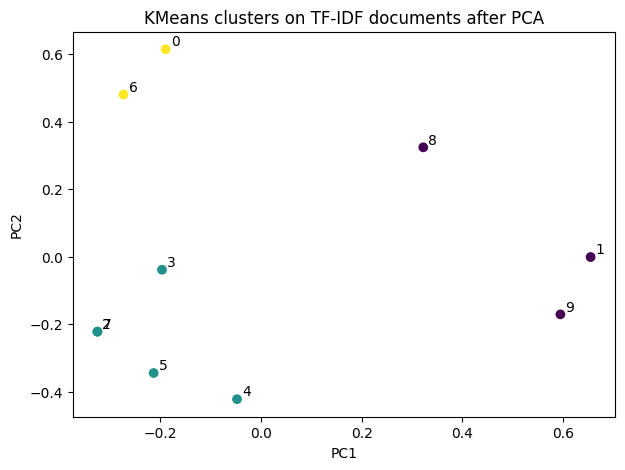

In [8]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

true_labels = ['movie_ai','movie_ai','sports','sports','programming','programming','movie_ai','sports','movie_ai','programming']

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_tfidf)

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_tfidf.toarray())
cluster_df = pd.DataFrame({
    'doc_id': range(len(docs)),
    'text': docs,
    'manual_label': true_labels,
    'cluster': cluster_labels,
    'x': coords[:,0],
    'y': coords[:,1],
})
display(cluster_df[['doc_id','manual_label','cluster','text']])

plt.figure(figsize=(7,5))
plt.scatter(cluster_df['x'], cluster_df['y'], c=cluster_df['cluster'])
for _, r in cluster_df.iterrows():
    plt.text(r['x']+0.01, r['y']+0.01, str(r['doc_id']))
plt.title('KMeans clusters on TF-IDF documents after PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


### 文档聚类讨论

KMeans 聚类与人工标签通常能部分一致：体育类文档词汇比较集中，容易聚到一起；编程类文档也有 `python`、`software`、`algorithms` 等明显标志。但 `movie_ai` 标签本身比较混合，既包含电影词，也包含 AI/推荐系统词，可能被拆到不同簇里。聚类错误的文档往往具有跨主题特征，例如“科幻电影 + 人工智能”同时像娱乐和科技。这里既有向量表示的原因，也有算法限制：TF-IDF 不理解深层语义，PCA 会压缩信息，KMeans 又假设簇近似球形，无法很好处理语义交叉的文本。


### 作答 5.2.2-3：从 BoW 到词向量 / 预训练模型

BoW/TF-IDF 把文本表示成词表空间中的稀疏向量，核心是统计“哪些词出现了、出现得多不多、区分度强不强”。它基本不理解词序和上下文。词向量和预训练模型则把词或文本映射到连续稠密向量空间，能表达语义相似性；BERT、GPT 这类模型还会结合上下文，同一个词在不同句子中可以有不同表示。

不过 BoW/TF-IDF 仍然有价值。它训练快、成本低、可解释性强，在小数据、关键词明显、搜索检索、新闻分类、作业项目原型中非常实用。课程项目中应优先尝试 BoW/TF-IDF + 逻辑回归、朴素贝叶斯、SVM、KMeans 等传统方法，先建立可运行 baseline，明确数据质量和任务难点；只有当简单方法效果不足，且确实需要语义理解、上下文建模或大规模泛化时，再上词向量或预训练模型。这样能避免一开始就使用复杂模型，导致成本高、调参难、结果不可解释。
